# Traditional ML Experiments - Energy Consumption Prediction

**Phase 2:** Traditional Machine Learning Models

## Overview

This notebook runs 3 experiments to measure the value of feature engineering:

1. **Experiment 1: Baseline** - Raw features only (17 columns)
2. **Experiment 2: Time** - Raw + time features (22 columns)
3. **Experiment 3: Full** - Raw + time + lag + rolling (30 columns)

For each experiment, we'll train:
- Linear Regression (sanity check)
- Random Forest
- XGBoost
- LightGBM

## Evaluation Strategy

- **Metrics:** MAE, RMSE, MAPE, R²
- **Split:** TimeSeriesSplit (5 folds) - respects temporal order
- **Preprocessing:** StandardScaler for numerical features, OneHotEncoder for categorical

## Success Criteria

- R² > 0.7
- MAE < 20% of mean energy consumption
- Clear improvement: Baseline → Time → Full

---
## 1. Imports and Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ Libraries imported successfully
Pandas version: 1.1.5
NumPy version: 1.19.5


---
## 2. Helper Functions

In [14]:
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(y_true, y_pred, dataset_name=""):
    """Calculate all evaluation metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = calculate_mape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    results = {
        'Dataset': dataset_name,
        'MAE (W)': mae,
        'RMSE (W)': rmse,
        'MAPE (%)': mape,
        'R²': r2
    }
    
    return results

def print_metrics(results):
    """Pretty print evaluation metrics"""
    print(f"\n{'='*60}")
    print(f"Evaluation Metrics - {results['Dataset']}")
    print(f"{'='*60}")
    print(f"  MAE:   {results['MAE (W)']:>8.2f} W")
    print(f"  RMSE:  {results['RMSE (W)']:>8.2f} W")
    print(f"  MAPE:  {results['MAPE (%)']:>8.2f} %")
    print(f"  R²:    {results['R²']:>8.4f}")
    print(f"{'='*60}")

def plot_predictions(y_true, y_pred, title="Actual vs Predicted", sample_size=1000):
    """Plot actual vs predicted values"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot (sample for visibility)
    idx = np.random.choice(len(y_true), min(sample_size, len(y_true)), replace=False)
    axes[0].scatter(y_true[idx], y_pred[idx], alpha=0.3, s=10)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
                 'r--', linewidth=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Energy (W)')
    axes[0].set_ylabel('Predicted Energy (W)')
    axes[0].set_title(f'{title}\nScatter Plot')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Residual plot
    residuals = y_true - y_pred
    axes[1].scatter(y_pred[idx], residuals[idx], alpha=0.3, s=10)
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted Energy (W)')
    axes[1].set_ylabel('Residuals (W)')
    axes[1].set_title(f'{title}\nResidual Plot')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✓ Helper functions defined")

✓ Helper functions defined


---
## 3. Load Data - All Three Variants

In [15]:
print("="*80)
print("LOADING PREPROCESSED DATA")
print("="*80)

# Load all three variants
df_baseline = pd.read_csv('../processed_data/netop_ml_baseline.csv')
df_time = pd.read_csv('../processed_data/netop_ml_time.csv')
df_full = pd.read_csv('../processed_data/netop_ml_full.csv')

print(f"\n✓ Baseline: {df_baseline.shape[0]:,} rows × {df_baseline.shape[1]} columns")
print(f"✓ Time:     {df_time.shape[0]:,} rows × {df_time.shape[1]} columns")
print(f"✓ Full:     {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")

# Verify no missing values
print(f"\n🔍 Data Quality Check:")
print(f"  Baseline missing values: {df_baseline.isnull().sum().sum()}")
print(f"  Time missing values:     {df_time.isnull().sum().sum()}")
print(f"  Full missing values:     {df_full.isnull().sum().sum()}")

# Show energy statistics
print(f"\n📊 Target Variable (Energy) Statistics:")
print(f"  Mean:   {df_baseline['Energy'].mean():.2f} W")
print(f"  Std:    {df_baseline['Energy'].std():.2f} W")
print(f"  Min:    {df_baseline['Energy'].min():.2f} W")
print(f"  Max:    {df_baseline['Energy'].max():.2f} W")
print(f"  Median: {df_baseline['Energy'].median():.2f} W")

LOADING PREPROCESSED DATA

✓ Baseline: 72,569 rows × 17 columns
✓ Time:     72,569 rows × 22 columns
✓ Full:     72,569 rows × 30 columns

🔍 Data Quality Check:
  Baseline missing values: 0
  Time missing values:     0
  Full missing values:     0

📊 Target Variable (Energy) Statistics:
  Mean:   28.64 W
  Std:    13.93 W
  Min:    3.59 W
  Max:    100.00 W
  Median: 24.66 W


---
## 4. Experiment 1: Baseline (Raw Features Only)

**Data:** `netop_ml_baseline.csv` (17 columns)

**Features:** load, ESMode1-6, RUType, Mode, Frequency, Bandwidth, Antennas, TXpower

**Goal:** Establish baseline performance with raw features only

In [16]:
print("="*80)
print("EXPERIMENT 1: BASELINE (Raw Features Only)")
print("="*80)

# Separate features and target
exclude_cols = ['Time', 'BS', 'CellName', 'Energy']
feature_cols_baseline = [col for col in df_baseline.columns if col not in exclude_cols]

print(f"\n📋 Features ({len(feature_cols_baseline)}):")
print(f"  {feature_cols_baseline}")

X_baseline = df_baseline[feature_cols_baseline]
y_baseline = df_baseline['Energy']

print(f"\n✓ X shape: {X_baseline.shape}")
print(f"✓ y shape: {y_baseline.shape}")

EXPERIMENT 1: BASELINE (Raw Features Only)

📋 Features (13):
  ['load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower']

✓ X shape: (72569, 13)
✓ y shape: (72569,)


### 4.1 Temporal Train-Test Split

**Important:** We use temporal split (not random) to respect time series nature:
- **Training set (80%):** First 80% of data for cross-validation and model training
- **Test set (20%):** Last 20% of data held out for final evaluation

This prevents data leakage and ensures proper generalization testing.

In [17]:
print("\n" + "="*80)
print("TEMPORAL TRAIN-TEST SPLIT")
print("="*80)

# Calculate split point (80/20 temporal split)
split_idx = int(len(X_baseline) * 0.8)

# Split features and target
X_train_full = X_baseline.iloc[:split_idx]
y_train_full = y_baseline.iloc[:split_idx]
X_test = X_baseline.iloc[split_idx:]
y_test = y_baseline.iloc[split_idx:]

print(f"\nTotal samples: {len(X_baseline):,}")
print(f"Training set: {len(X_train_full):,} samples (80%)")
print(f"Test set: {len(X_test):,} samples (20%)")

# Show temporal boundaries
print(f"\n📅 Temporal boundaries:")
print(f"  Training: {df_baseline['Time'].iloc[0]} to {df_baseline['Time'].iloc[split_idx-1]}")
print(f"  Test:     {df_baseline['Time'].iloc[split_idx]} to {df_baseline['Time'].iloc[-1]}")

print(f"\n✓ Temporal split complete")


TEMPORAL TRAIN-TEST SPLIT

Total samples: 72,569
Training set: 58,055 samples (80%)
Test set: 14,514 samples (20%)

📅 Temporal boundaries:
  Training: 2023-01-02 06:00:00 to 2023-01-02 23:00:00
  Test:     2023-01-03 00:00:00 to 2023-01-07 13:00:00

✓ Temporal split complete


### 4.2 Preprocessing Pipeline Setup

In [18]:
# Identify numerical and categorical features
categorical_features = ['RUType', 'Mode']
numerical_features = [col for col in feature_cols_baseline if col not in categorical_features]

print(f"\n🔢 Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"🏷️  Categorical features ({len(categorical_features)}): {categorical_features}")

# Create preprocessing pipeline
preprocessor_baseline = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse=False), categorical_features)
    ])

print("\n✓ Preprocessing pipeline created")


🔢 Numerical features (11): ['load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower']
🏷️  Categorical features (2): ['RUType', 'Mode']

✓ Preprocessing pipeline created


### 4.3 Time Series Cross-Validation Setup

In [19]:
# TimeSeriesSplit with 5 folds
tscv = TimeSeriesSplit(n_splits=5)

print("\n📅 Time Series Cross-Validation Setup:")
print(f"  Number of splits: 5")
print(f"  Total samples: {len(X_baseline):,}")
print(f"\n  Fold sizes:")

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_baseline), 1):
    print(f"    Fold {fold_idx}: Train={len(train_idx):>6,} | Val={len(val_idx):>6,}")


📅 Time Series Cross-Validation Setup:
  Number of splits: 5
  Total samples: 72,569

  Fold sizes:
    Fold 1: Train=12,099 | Val=12,094
    Fold 2: Train=24,193 | Val=12,094
    Fold 3: Train=36,287 | Val=12,094
    Fold 4: Train=48,381 | Val=12,094
    Fold 5: Train=60,475 | Val=12,094


### 4.3 Model 1: Linear Regression (Sanity Check)

In [20]:
print("\n" + "="*60)
print("Model 1: Linear Regression (Baseline)")
print("="*60)

# Create pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_baseline),
    ('regressor', LinearRegression())
])

# Cross-validation on TRAINING SET ONLY
lr_results = []
for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_full), 1):
    # Split data
    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    
    # Train
    lr_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = lr_pipeline.predict(X_val)
    
    # Evaluate
    results = evaluate_model(y_val.values, y_pred, f"Fold {fold_idx}")
    lr_results.append(results)
    
    print(f"  Fold {fold_idx}: MAE={results['MAE (W)']:>6.2f} W | RMSE={results['RMSE (W)']:>6.2f} W | R²={results['R²']:>6.4f}")

# Average results
lr_avg = pd.DataFrame(lr_results).mean()
print(f"\n  {'='*58}")
print(f"  CV Avg: MAE={lr_avg['MAE (W)']:>6.2f} W | RMSE={lr_avg['RMSE (W)']:>6.2f} W | R²={lr_avg['R²']:>6.4f}")
print(f"  {'='*58}")

# Train on FULL TRAINING SET
print("\n  Training on full training set...")
lr_pipeline.fit(X_train_full, y_train_full)

# Evaluate on TEST SET
y_pred_test_lr = lr_pipeline.predict(X_test)
lr_test_results = evaluate_model(y_test.values, y_pred_test_lr, "Test Set")

print(f"\n  {'='*58}")
print(f"  Test:   MAE={lr_test_results['MAE (W)']:>6.2f} W | RMSE={lr_test_results['RMSE (W)']:>6.2f} W | R²={lr_test_results['R²']:>6.4f}")
print(f"  {'='*58}")

print("\n✓ Linear Regression training complete")


Model 1: Linear Regression (Baseline)
  Fold 1: MAE=1510802576173.63 W | RMSE=11974867419540.97 W | R²=-943610791002393957892096.0000
  Fold 2: MAE=  3.95 W | RMSE=  5.39 W | R²=0.8641
  Fold 3: MAE=  4.35 W | RMSE=  5.96 W | R²=0.8121
  Fold 4: MAE=  4.31 W | RMSE=  5.86 W | R²=0.8091
  Fold 5: MAE=  3.35 W | RMSE=  4.49 W | R²=0.8799

  CV Avg: MAE=302160515237.92 W | RMSE=2394973483912.53 W | R²=-188722158200478805000192.0000

  Training on full training set...

  Test:   MAE=  3.55 W | RMSE=  4.96 W | R²=0.8756

✓ Linear Regression training complete


### 4.4 Model 2: Random Forest

In [21]:
print("\n" + "="*60)
print("Model 2: Random Forest (Baseline)")
print("="*60)

# Create pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_baseline),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    ))
])

# Cross-validation on TRAINING SET ONLY
rf_results = []
for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_full), 1):
    print(f"  Training Fold {fold_idx}...", end=" ")
    
    # Split data
    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    
    # Train
    rf_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = rf_pipeline.predict(X_val)
    
    # Evaluate
    results = evaluate_model(y_val.values, y_pred, f"Fold {fold_idx}")
    rf_results.append(results)
    
    print(f"MAE={results['MAE (W)']:>6.2f} W | RMSE={results['RMSE (W)']:>6.2f} W | R²={results['R²']:>6.4f}")

# Average results
rf_avg = pd.DataFrame(rf_results).mean()
print(f"\n  {'='*58}")
print(f"  CV Avg: MAE={rf_avg['MAE (W)']:>6.2f} W | RMSE={rf_avg['RMSE (W)']:>6.2f} W | R²={rf_avg['R²']:>6.4f}")
print(f"  {'='*58}")

# Train on FULL TRAINING SET
print("\n  Training on full training set...")
rf_pipeline.fit(X_train_full, y_train_full)

# Evaluate on TEST SET
y_pred_test_rf = rf_pipeline.predict(X_test)
rf_test_results = evaluate_model(y_test.values, y_pred_test_rf, "Test Set")

print(f"\n  {'='*58}")
print(f"  Test:   MAE={rf_test_results['MAE (W)']:>6.2f} W | RMSE={rf_test_results['RMSE (W)']:>6.2f} W | R²={rf_test_results['R²']:>6.4f}")
print(f"  {'='*58}")

print("\n✓ Random Forest training complete")


Model 2: Random Forest (Baseline)
  Training Fold 1... MAE=  3.69 W | RMSE=  5.21 W | R²=0.8211
  Training Fold 2... MAE=  3.71 W | RMSE=  5.23 W | R²=0.8722
  Training Fold 3... MAE=  3.92 W | RMSE=  5.58 W | R²=0.8352
  Training Fold 4... MAE=  4.19 W | RMSE=  6.16 W | R²=0.7888
  Training Fold 5... MAE=  3.21 W | RMSE=  4.45 W | R²=0.8825

  CV Avg: MAE=  3.74 W | RMSE=  5.33 W | R²=0.8400

  Training on full training set...

  Test:   MAE=  3.48 W | RMSE=  5.13 W | R²=0.8669

✓ Random Forest training complete


### 4.5 Model 3: XGBoost

In [22]:
print("\n" + "="*60)
print("Model 3: XGBoost (Baseline)")
print("="*60)

# Create pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_baseline),
    ('regressor', XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ))
])

# Cross-validation on TRAINING SET ONLY
xgb_results = []
for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_full), 1):
    print(f"  Training Fold {fold_idx}...", end=" ")
    
    # Split data
    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    
    # Train
    xgb_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = xgb_pipeline.predict(X_val)
    
    # Evaluate
    results = evaluate_model(y_val.values, y_pred, f"Fold {fold_idx}")
    xgb_results.append(results)
    
    print(f"MAE={results['MAE (W)']:>6.2f} W | RMSE={results['RMSE (W)']:>6.2f} W | R²={results['R²']:>6.4f}")

# Average results
xgb_avg = pd.DataFrame(xgb_results).mean()
print(f"\n  {'='*58}")
print(f"  CV Avg: MAE={xgb_avg['MAE (W)']:>6.2f} W | RMSE={xgb_avg['RMSE (W)']:>6.2f} W | R²={xgb_avg['R²']:>6.4f}")
print(f"  {'='*58}")

# Train on FULL TRAINING SET
print("\n  Training on full training set...")
xgb_pipeline.fit(X_train_full, y_train_full)

# Evaluate on TEST SET
y_pred_test_xgb = xgb_pipeline.predict(X_test)
xgb_test_results = evaluate_model(y_test.values, y_pred_test_xgb, "Test Set")

print(f"\n  {'='*58}")
print(f"  Test:   MAE={xgb_test_results['MAE (W)']:>6.2f} W | RMSE={xgb_test_results['RMSE (W)']:>6.2f} W | R²={xgb_test_results['R²']:>6.4f}")
print(f"  {'='*58}")

print("\n✓ XGBoost training complete")


Model 3: XGBoost (Baseline)
  Training Fold 1... MAE=  3.36 W | RMSE=  4.71 W | R²=0.8541
  Training Fold 2... MAE=  3.59 W | RMSE=  5.10 W | R²=0.8783
  Training Fold 3... MAE=  3.75 W | RMSE=  5.32 W | R²=0.8502
  Training Fold 4... MAE=  4.11 W | RMSE=  5.79 W | R²=0.8133
  Training Fold 5... MAE=  2.96 W | RMSE=  4.05 W | R²=0.9023

  CV Avg: MAE=  3.55 W | RMSE=  4.99 W | R²=0.8596

  Training on full training set...

  Test:   MAE=  3.34 W | RMSE=  4.86 W | R²=0.8806

✓ XGBoost training complete


### 4.6 Model 4: LightGBM

In [23]:
print("\n" + "="*60)
print("Model 4: LightGBM (Baseline)")
print("="*60)

# Create pipeline
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor_baseline),
    ('regressor', LGBMRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ))
])

# Cross-validation on TRAINING SET ONLY
lgbm_results = []
for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_full), 1):
    print(f"  Training Fold {fold_idx}...", end=" ")
    
    # Split data
    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    
    # Train
    lgbm_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = lgbm_pipeline.predict(X_val)
    
    # Evaluate
    results = evaluate_model(y_val.values, y_pred, f"Fold {fold_idx}")
    lgbm_results.append(results)
    
    print(f"MAE={results['MAE (W)']:>6.2f} W | RMSE={results['RMSE (W)']:>6.2f} W | R²={results['R²']:>6.4f}")

# Average results
lgbm_avg = pd.DataFrame(lgbm_results).mean()
print(f"\n  {'='*58}")
print(f"  CV Avg: MAE={lgbm_avg['MAE (W)']:>6.2f} W | RMSE={lgbm_avg['RMSE (W)']:>6.2f} W | R²={lgbm_avg['R²']:>6.4f}")
print(f"  {'='*58}")

# Train on FULL TRAINING SET
print("\n  Training on full training set...")
lgbm_pipeline.fit(X_train_full, y_train_full)

# Evaluate on TEST SET
y_pred_test_lgbm = lgbm_pipeline.predict(X_test)
lgbm_test_results = evaluate_model(y_test.values, y_pred_test_lgbm, "Test Set")

print(f"\n  {'='*58}")
print(f"  Test:   MAE={lgbm_test_results['MAE (W)']:>6.2f} W | RMSE={lgbm_test_results['RMSE (W)']:>6.2f} W | R²={lgbm_test_results['R²']:>6.4f}")
print(f"  {'='*58}")

print("\n✓ LightGBM training complete")


Model 4: LightGBM (Baseline)
  Training Fold 1... MAE=  3.56 W | RMSE=  5.51 W | R²=0.8002
  Training Fold 2... MAE=  3.50 W | RMSE=  4.86 W | R²=0.8894
  Training Fold 3... MAE=  3.75 W | RMSE=  5.34 W | R²=0.8491
  Training Fold 4... MAE=  4.06 W | RMSE=  5.78 W | R²=0.8140
  Training Fold 5... MAE=  3.07 W | RMSE=  4.19 W | R²=0.8956

  CV Avg: MAE=  3.59 W | RMSE=  5.14 W | R²=0.8496

  Training on full training set...

  Test:   MAE=  3.34 W | RMSE=  4.79 W | R²=0.8837

✓ LightGBM training complete


### 4.7 Experiment 1 Summary

In [24]:
print("\n" + "="*80)
print("EXPERIMENT 1: BASELINE - SUMMARY")
print("="*80)

# Compile CV results
exp1_cv_summary = pd.DataFrame([
    {'Model': 'Linear Regression', **{k: v for k, v in lr_avg.items() if k != 'Dataset'}},
    {'Model': 'Random Forest', **{k: v for k, v in rf_avg.items() if k != 'Dataset'}},
    {'Model': 'XGBoost', **{k: v for k, v in xgb_avg.items() if k != 'Dataset'}},
    {'Model': 'LightGBM', **{k: v for k, v in lgbm_avg.items() if k != 'Dataset'}}
])

# Compile test results
exp1_test_summary = pd.DataFrame([
    {'Model': 'Linear Regression', **{k: v for k, v in lr_test_results.items() if k != 'Dataset'}},
    {'Model': 'Random Forest', **{k: v for k, v in rf_test_results.items() if k != 'Dataset'}},
    {'Model': 'XGBoost', **{k: v for k, v in xgb_test_results.items() if k != 'Dataset'}},
    {'Model': 'LightGBM', **{k: v for k, v in lgbm_test_results.items() if k != 'Dataset'}}
])

# Sort by R² descending
exp1_cv_summary = exp1_cv_summary.sort_values('R²', ascending=False)
exp1_test_summary = exp1_test_summary.sort_values('R²', ascending=False)

print("\n📊 Cross-Validation Results (5-fold average on training set):")
print(exp1_cv_summary.to_string(index=False))

print("\n📊 Test Set Results (held-out 20%):") 
print(exp1_test_summary.to_string(index=False))

# Find best model (by test R²)
best_model_exp1 = exp1_test_summary.iloc[0]['Model']
best_r2_exp1 = exp1_test_summary.iloc[0]['R²']
best_mae_exp1 = exp1_test_summary.iloc[0]['MAE (W)']

print(f"\n🏆 Best Model (Test Set): {best_model_exp1}")
print(f"   Test R² = {best_r2_exp1:.4f} | Test MAE = {best_mae_exp1:.2f} W")

# Check success criteria (on test set)
mean_energy = y_test.mean()
mae_threshold = 0.20 * mean_energy  # 20% of mean

print(f"\n✅ Success Criteria Check (Test Set):")
print(f"   R² > 0.7:          {'✓ PASS' if best_r2_exp1 > 0.7 else '✗ FAIL'} ({best_r2_exp1:.4f})")
print(f"   MAE < 20% of mean: {'✓ PASS' if best_mae_exp1 < mae_threshold else '✗ FAIL'} ({best_mae_exp1:.2f} W < {mae_threshold:.2f} W)")

# Store for saving
exp1_summary = exp1_test_summary


EXPERIMENT 1: BASELINE - SUMMARY

📊 Cross-Validation Results (5-fold average on training set):
             Model       MAE (W)      RMSE (W)      MAPE (%)            R²
           XGBoost  3.552098e+00  4.994555e+00  1.400453e+01  8.596444e-01
          LightGBM  3.587896e+00  5.136497e+00  1.414344e+01  8.496472e-01
     Random Forest  3.742775e+00  5.325012e+00  1.471399e+01  8.399540e-01
 Linear Regression  3.021605e+11  2.394973e+12  7.395150e+11 -1.887222e+23

📊 Test Set Results (held-out 20%):
             Model   MAE (W)  RMSE (W)   MAPE (%)        R²
          LightGBM  3.340572  4.791432  12.286080  0.883720
           XGBoost  3.343177  4.855669  12.326125  0.880581
 Linear Regression  3.546813  4.955898  13.669593  0.875600
     Random Forest  3.484784  5.126144  12.902788  0.866907

🏆 Best Model (Test Set): LightGBM
   Test R² = 0.8837 | Test MAE = 3.34 W

✅ Success Criteria Check (Test Set):
   R² > 0.7:          ✓ PASS (0.8837)
   MAE < 20% of mean: ✓ PASS (3.34 W < 5.8

### 4.8 Visualize Best Model (Baseline)

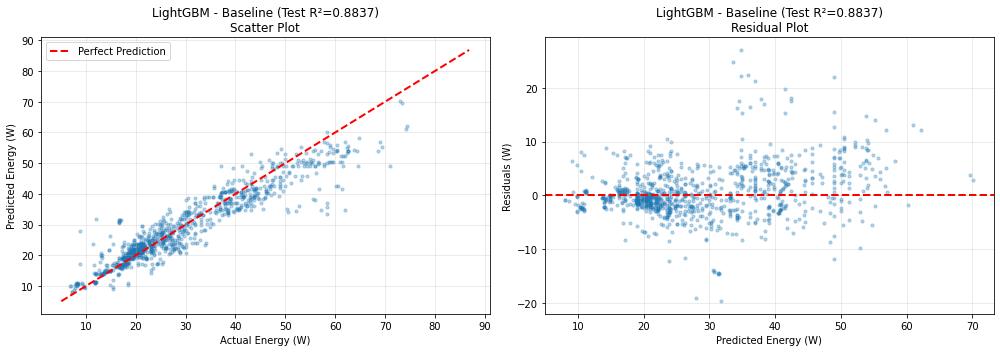

In [25]:
# Plot predictions for best model on TEST SET
if best_model_exp1 == 'XGBoost':
    plot_predictions(y_test.values, y_pred_test_xgb, f"XGBoost - Baseline (Test R²={best_r2_exp1:.4f})")
elif best_model_exp1 == 'LightGBM':
    plot_predictions(y_test.values, y_pred_test_lgbm, f"LightGBM - Baseline (Test R²={best_r2_exp1:.4f})")
elif best_model_exp1 == 'Random Forest':
    plot_predictions(y_test.values, y_pred_test_rf, f"Random Forest - Baseline (Test R²={best_r2_exp1:.4f})")
else:
    plot_predictions(y_test.values, y_pred_test_lr, f"Linear Regression - Baseline (Test R²={best_r2_exp1:.4f})")

### 4.9 Feature Importance Analysis

In [26]:
print("="*80)
print("FEATURE IMPORTANCE ANALYSIS - BASELINE")
print("="*80)

print("\nNote: Feature importance extracted from models trained on full training set (80% of data)")

# Get feature names after preprocessing
# The preprocessor has already been fitted during training
num_feature_names = numerical_features

# Get categorical feature names after one-hot encoding
cat_encoder = preprocessor_baseline.named_transformers_['cat']
cat_feature_names = []
for i, cat in enumerate(categorical_features):
    # Get categories for this feature (excluding the first one due to drop='first')
    categories = cat_encoder.categories_[i][1:]  # Skip first category
    cat_feature_names.extend([f"{cat}_{cat_val}" for cat_val in categories])

# Combine all feature names
all_feature_names = num_feature_names + cat_feature_names

print(f"\n📋 Total features after preprocessing: {len(all_feature_names)}")
print(f"   Numerical: {len(num_feature_names)}")
print(f"   Categorical (one-hot): {len(cat_feature_names)}")

# Extract feature importance from each model
print("\n" + "="*80)
print("Extracting Feature Importances...")
print("="*80)

# XGBoost
xgb_importance = xgb_pipeline.named_steps['regressor'].feature_importances_
xgb_fi_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False)

print("\n🥇 XGBoost - Top 10 Features:")
print(xgb_fi_df.head(10).to_string(index=False))

# LightGBM
lgbm_importance = lgbm_pipeline.named_steps['regressor'].feature_importances_
lgbm_fi_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': lgbm_importance
}).sort_values('Importance', ascending=False)

print("\n🥈 LightGBM - Top 10 Features:")
print(lgbm_fi_df.head(10).to_string(index=False))

# Random Forest
rf_importance = rf_pipeline.named_steps['regressor'].feature_importances_
rf_fi_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)

print("\n🥉 Random Forest - Top 10 Features:")
print(rf_fi_df.head(10).to_string(index=False))

FEATURE IMPORTANCE ANALYSIS - BASELINE

Note: Feature importance extracted from models trained on full training set (80% of data)

📋 Total features after preprocessing: 17
   Numerical: 11
   Categorical (one-hot): 6

Extracting Feature Importances...

🥇 XGBoost - Top 10 Features:
      Feature  Importance
     Antennas    0.250272
 RUType_Type7    0.228487
    Frequency    0.215006
         load    0.081147
 RUType_Type3    0.048260
 RUType_Type6    0.047170
 RUType_Type5    0.028387
 RUType_Type4    0.025273
      TXpower    0.023466
 RUType_Type2    0.014050

🥈 LightGBM - Top 10 Features:
      Feature  Importance
         load         927
      TXpower         413
    Frequency         387
     Antennas         271
      ESMode2         128
 RUType_Type7         123
      ESMode1         121
 RUType_Type5          95
 RUType_Type2          94
 RUType_Type4          66

🥉 Random Forest - Top 10 Features:
      Feature  Importance
         load    0.490727
     Antennas    0.171860
 

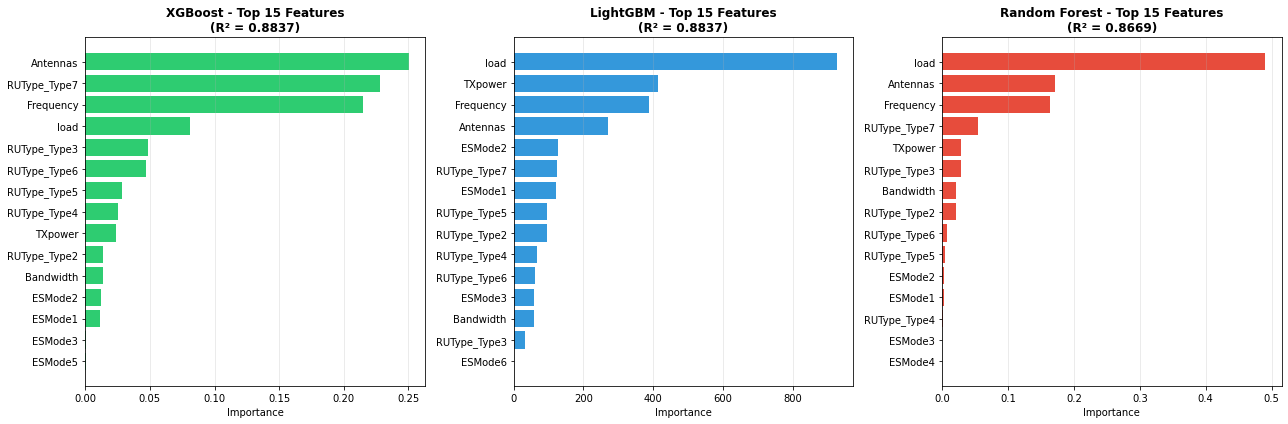


✓ Feature importance visualization complete


In [27]:
# Visualize feature importance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
top_n = 15
xgb_top = xgb_fi_df.head(top_n)
axes[0].barh(range(len(xgb_top)), xgb_top['Importance'], color='#2ecc71')
axes[0].set_yticks(range(len(xgb_top)))
axes[0].set_yticklabels(xgb_top['Feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title(f'XGBoost - Top {top_n} Features\n(R² = {best_r2_exp1:.4f})', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# LightGBM
lgbm_top = lgbm_fi_df.head(top_n)
axes[1].barh(range(len(lgbm_top)), lgbm_top['Importance'], color='#3498db')
axes[1].set_yticks(range(len(lgbm_top)))
axes[1].set_yticklabels(lgbm_top['Feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance')
lgbm_r2 = exp1_summary[exp1_summary['Model'] == 'LightGBM']['R²'].values[0]
axes[1].set_title(f'LightGBM - Top {top_n} Features\n(R² = {lgbm_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Random Forest
rf_top = rf_fi_df.head(top_n)
axes[2].barh(range(len(rf_top)), rf_top['Importance'], color='#e74c3c')
axes[2].set_yticks(range(len(rf_top)))
axes[2].set_yticklabels(rf_top['Feature'])
axes[2].invert_yaxis()
axes[2].set_xlabel('Importance')
rf_r2 = exp1_summary[exp1_summary['Model'] == 'Random Forest']['R²'].values[0]
axes[2].set_title(f'Random Forest - Top {top_n} Features\n(R² = {rf_r2:.4f})', fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Feature importance visualization complete")


CONSENSUS FEATURE IMPORTANCE

📊 Top 15 Features by Average Importance (across all 3 models):
      Feature   Average       Std   XGBoost  LightGBM  RandomForest
 RUType_Type7  0.774745  0.390154  0.324234  1.000000      1.000000
         load  0.547519  0.392927  1.000000  0.292341      0.350215
    Bandwidth  0.536924  0.282092  0.859088  0.417476      0.334207
 RUType_Type5  0.385139  0.457243  0.912953  0.132686      0.109779
 RUType_Type6  0.199622  0.213641  0.093763  0.445523      0.059580
      TXpower  0.095242  0.085352  0.192831  0.034520      0.058376
 RUType_Type4  0.088914  0.089940  0.188474  0.064725      0.013541
 RUType_Type3  0.075340  0.056751  0.113424  0.102481      0.010114
     Antennas  0.066692  0.030820  0.056140  0.101402      0.042534
      ESMode3  0.064395  0.066939  0.047772  0.138080      0.007334
      ESMode2  0.061065  0.063552  0.046825  0.130529      0.005841
 RUType_Type2  0.058142  0.050645  0.100982  0.071197      0.002248
      ESMode1  0.05409

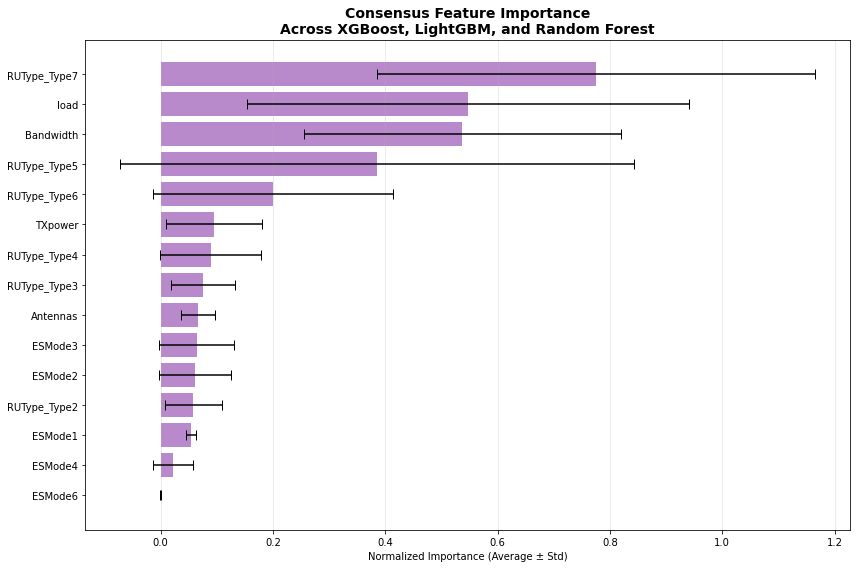


✓ Consensus analysis complete


In [28]:
# Consensus analysis - which features are consistently important?
print("\n" + "="*80)
print("CONSENSUS FEATURE IMPORTANCE")
print("="*80)

# Normalize importances to 0-1 scale for fair comparison
xgb_fi_df['Importance_Norm'] = xgb_fi_df['Importance'] / xgb_fi_df['Importance'].max()
lgbm_fi_df['Importance_Norm'] = lgbm_fi_df['Importance'] / lgbm_fi_df['Importance'].max()
rf_fi_df['Importance_Norm'] = rf_fi_df['Importance'] / rf_fi_df['Importance'].max()

# Create consensus dataframe
consensus_df = pd.DataFrame({
    'Feature': all_feature_names,
    'XGBoost': xgb_fi_df.set_index('Feature')['Importance_Norm'],
    'LightGBM': lgbm_fi_df.set_index('Feature')['Importance_Norm'],
    'RandomForest': rf_fi_df.set_index('Feature')['Importance_Norm']
})

# Calculate average importance across all models
consensus_df['Average'] = consensus_df[['XGBoost', 'LightGBM', 'RandomForest']].mean(axis=1)
consensus_df['Std'] = consensus_df[['XGBoost', 'LightGBM', 'RandomForest']].std(axis=1)

# Sort by average importance
consensus_df = consensus_df.sort_values('Average', ascending=False)

print("\n📊 Top 15 Features by Average Importance (across all 3 models):")
print(consensus_df[['Feature', 'Average', 'Std', 'XGBoost', 'LightGBM', 'RandomForest']].head(15).to_string(index=False))

# Visualize consensus
fig, ax = plt.subplots(figsize=(12, 8))
top_consensus = consensus_df.head(15)
x = range(len(top_consensus))

ax.barh(x, top_consensus['Average'], xerr=top_consensus['Std'], 
        color='#9b59b6', alpha=0.7, capsize=5)
ax.set_yticks(x)
ax.set_yticklabels(top_consensus['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Normalized Importance (Average ± Std)')
ax.set_title('Consensus Feature Importance\nAcross XGBoost, LightGBM, and Random Forest', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Consensus analysis complete")

---
## 5. Save Experiment 1 Results

In [29]:
# Save results to CSV
exp1_summary.to_csv('../results/traditional_ml_baseline_results.csv', index=False)
print("✓ Experiment 1 results saved to ../results/traditional_ml_baseline_results.csv")

# Save best model
import joblib
if best_model_exp1 == 'XGBoost':
    joblib.dump(xgb_pipeline, '../models/xgboost_baseline.pkl')
    print("✓ Best model (XGBoost) saved to ../models/xgboost_baseline.pkl")
elif best_model_exp1 == 'LightGBM':
    joblib.dump(lgbm_pipeline, '../models/lightgbm_baseline.pkl')
    print("✓ Best model (LightGBM) saved to ../models/lightgbm_baseline.pkl")
elif best_model_exp1 == 'Random Forest':
    joblib.dump(rf_pipeline, '../models/rf_baseline.pkl')
    print("✓ Best model (Random Forest) saved to ../models/rf_baseline.pkl")
else:
    joblib.dump(lr_pipeline, '../models/lr_baseline.pkl')
    print("✓ Best model (Linear Regression) saved to ../models/lr_baseline.pkl")

✓ Experiment 1 results saved to ../results/traditional_ml_baseline_results.csv
✓ Best model (LightGBM) saved to ../models/lightgbm_baseline.pkl


---
## Next: Experiment 2 (Time Features)

Continue with `netop_ml_time.csv` to measure the value of temporal features.

**Expected:** 10-25% improvement in MAE over Baseline